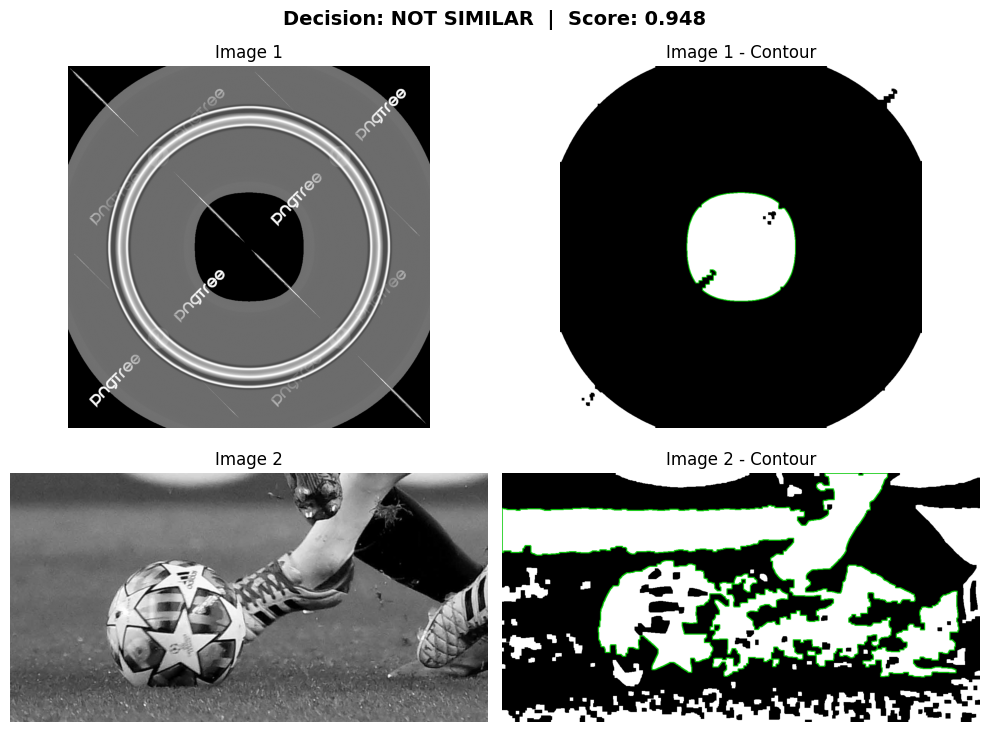

Hu moment distance          : 22.3917
Geometric distance          : 1.5954
matchShapes score           : 4.0269
Contour point distance      : 0.2221
Combined score (0-1)        : 0.9481

Decision: NOT SIMILAR  (threshold 0.35)


In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG1_PATH = "circle.png"
IMG2_PATH = "football.jpg"

#  Preprocessing

def to_binary(gray):
    # CLAHE normalizes uneven lighting / gradients before thresholding
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    blurred = cv2.GaussianBlur(enhanced, (7, 7), 0)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = np.ones((5, 5), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  kernel, iterations=2)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

    return fix_polarity(binary)

def fix_polarity(binary):
    h, w = binary.shape
    # Try both polarities, pick the one whose largest contour doesn't hug the image border
    for candidate in [binary, cv2.bitwise_not(binary)]:
        contours, _ = cv2.findContours(candidate, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        if not contours:
            continue
        c = max(contours, key=cv2.contourArea)
        x, y, cw, ch = cv2.boundingRect(c)
        touches_border = (x <= 2 or y <= 2 or x + cw >= w - 2 or y + ch >= h - 2)
        if not touches_border:
            return candidate
    # Fallback: return whichever has the smaller foreground (shape, not background)
    return binary if np.count_nonzero(binary) < np.count_nonzero(cv2.bitwise_not(binary)) else cv2.bitwise_not(binary)

def get_contour(binary):
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        raise ValueError("No contour found.")
    min_area = binary.shape[0] * binary.shape[1] * 0.001
    contours = [c for c in contours if cv2.contourArea(c) > min_area]
    return max(contours, key=cv2.contourArea)

#  Feature Extraction

def hu_log(contour):
    m = cv2.moments(contour)
    hu = cv2.HuMoments(m).flatten()
    return -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)

def geometric_features(contour):
    area      = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    x, y, w, h = cv2.boundingRect(contour)
    hull_area = cv2.contourArea(cv2.convexHull(contour))

    circularity  = (4 * np.pi * area / perimeter ** 2) if perimeter > 0 else 0
    solidity     = area / hull_area if hull_area > 0 else 0
    aspect_ratio = w / h if h > 0 else 0
    extent       = area / (w * h) if (w * h) > 0 else 0

    if len(contour) >= 5:
        (_, _), (ma, MA), _ = cv2.fitEllipse(contour)
        ellipse_ratio = ma / MA if MA > 0 else 0
    else:
        ellipse_ratio = aspect_ratio

    return np.array([circularity, solidity, aspect_ratio, extent, ellipse_ratio])

def contour_point_distance(c1, c2, n=100):
    def resample(c, n):
        c = c.reshape(-1, 2).astype(np.float32)
        idx = np.linspace(0, len(c) - 1, n).astype(int)
        return c[idx]

    def normalize(pts):
        pts = pts - pts.min(axis=0)
        s = pts.max()
        return pts / s if s > 0 else pts

    p1 = normalize(resample(c1, n))
    p2 = normalize(resample(c2, n))

    d1 = np.mean([np.min(np.linalg.norm(p2 - p, axis=1)) for p in p1])
    d2 = np.mean([np.min(np.linalg.norm(p1 - p, axis=1)) for p in p2])
    return (d1 + d2) / 2

#  Similarity Scoring

def compute_similarity(c1, c2):
    hu_dist      = np.linalg.norm(hu_log(c1) - hu_log(c2))
    geo_dist     = np.linalg.norm(geometric_features(c1) - geometric_features(c2))
    match_score  = cv2.matchShapes(c1, c2, cv2.CONTOURS_MATCH_I2, 0.0)
    contour_dist = contour_point_distance(c1, c2)

    score = (
        0.30 * min(hu_dist      / 2.0, 1.0) +
        0.25 * min(geo_dist     / 1.0, 1.0) +
        0.25 * min(match_score  / 0.3,  1.0) +
        0.20 * min(contour_dist / 0.3,  1.0)
    )

    return score, {
        "Hu moment distance"    : hu_dist,
        "Geometric distance"    : geo_dist,
        "matchShapes score"     : match_score,
        "Contour point distance": contour_dist,
        "Combined score (0-1)"  : score,
    }

#  Visualize

def visualize(gray1, binary1, c1, gray2, binary2, c2, score):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    label = "SIMILAR" if score < 0.35 else "NOT SIMILAR"
    fig.suptitle(f"Decision: {label}  |  Score: {score:.3f}", fontsize=14, fontweight="bold")

    for ax, gray, binary, contour, title in zip(
        axes.flat,
        [gray1, gray1, gray2, gray2],
        [binary1, binary1, binary2, binary2],
        [c1, c1, c2, c2],
        ["Image 1", "Image 1 - Contour", "Image 2", "Image 2 - Contour"],
    ):
        if "Contour" in title:
            canvas = cv2.cvtColor(binary, cv2.COLOR_GRAY2RGB)
            cv2.drawContours(canvas, [contour], -1, (0, 200, 0), 2)
            ax.imshow(canvas)
        else:
            ax.imshow(gray, cmap="gray")
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

#  Main

gray1 = cv2.imread(IMG1_PATH, cv2.IMREAD_GRAYSCALE)
gray2 = cv2.imread(IMG2_PATH, cv2.IMREAD_GRAYSCALE)

binary1, binary2 = to_binary(gray1), to_binary(gray2)
c1, c2           = get_contour(binary1), get_contour(binary2)

score, metrics = compute_similarity(c1, c2)
visualize(gray1, binary1, c1, gray2, binary2, c2, score)

for name, val in metrics.items():
    print(f"{name:<28}: {val:.4f}")

THRESHOLD = 0.35
print(f"\nDecision: {'SIMILAR' if score < THRESHOLD else 'NOT SIMILAR'}  (threshold {THRESHOLD})")